<a href="https://colab.research.google.com/github/Lok-Tung/Just-for-fun/blob/main/credit-risk-modeling/Credit_Risk_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Data Source: Give Me Some Credit (Kaggle)
# https://www.kaggle.com/competitions/GiveMeSomeCredit/overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

In [2]:
train = pd.read_csv('cs-training.csv', index_col=0)
print("Raw train shape:", train.shape)
print("Columns:", train.columns.tolist())
print("Default rate:", train['SeriousDlqin2yrs'].mean())

Raw train shape: (150000, 11)
Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']
Default rate: 0.06684


In [3]:
# Rename target
train = train.rename(columns={'SeriousDlqin2yrs': 'default'})

In [4]:
train.isna().sum()

,0
default,0
RevolvingUtilizationOfUnsecuredLines,0
age,0
NumberOfTime30-59DaysPastDueNotWorse,0
DebtRatio,0
MonthlyIncome,29731
NumberOfOpenCreditLinesAndLoans,0
NumberOfTimes90DaysLate,0
NumberRealEstateLoansOrLines,0
NumberOfTime60-89DaysPastDueNotWorse,0


In [5]:
# Impute missing
cols_to_impute = ['MonthlyIncome', 'NumberOfDependents']
imputer = SimpleImputer(strategy='median')
train[cols_to_impute] = imputer.fit_transform(train[cols_to_impute])

In [6]:
train['age'][train['age']<=18]

,age
65696,0


In [7]:
train = train[train['age']>18]

In [9]:
train.head()

,default,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [10]:
# Feature engineering
train['income_per_debt'] = train['MonthlyIncome'] / (train['DebtRatio'] + 0.001)
train['past_due_total'] = (
    train['NumberOfTime30-59DaysPastDueNotWorse']
    + train['NumberOfTime60-89DaysPastDueNotWorse']
    + train['NumberOfTimes90DaysLate']
)

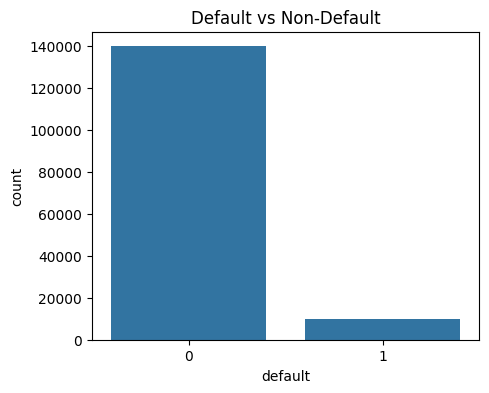

In [20]:
# === Default Rate Visualization ===
plt.figure(figsize=(5,4))
sns.countplot(data=train, x='default')
plt.title('Default vs Non-Default')
plt.show()

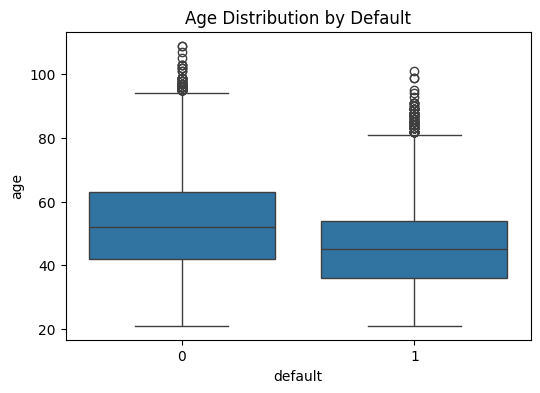

In [21]:
# === Age vs Default ===
plt.figure(figsize=(6,4))
sns.boxplot(data=train, x='default', y='age')
plt.title('Age Distribution by Default')
plt.show()

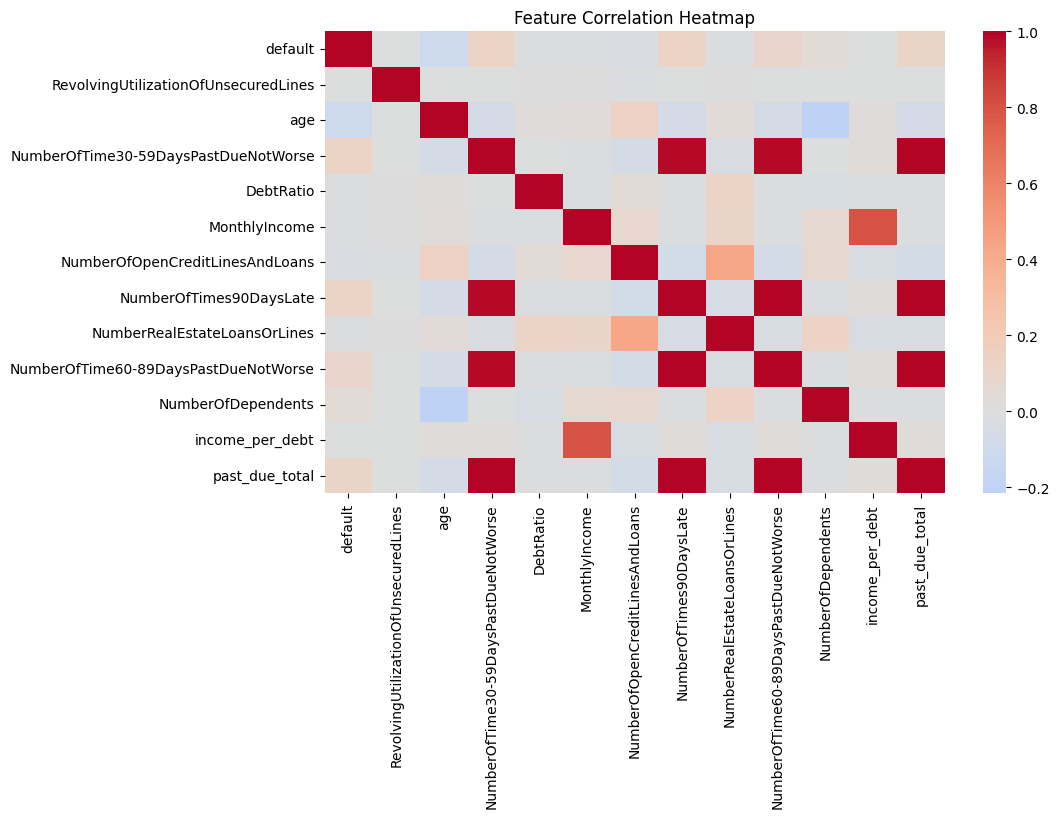

In [22]:
# === Correlation Heatmap ===
plt.figure(figsize=(10,6))
sns.heatmap(train.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [30]:
feature_cols = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'income_per_debt',
    'past_due_total'
]
X = train[feature_cols]
y = train['default']

In [31]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [41]:
# === Random Forest ===
rf = RandomForestClassifier(
    n_estimators=200, max_depth=8, random_state=42, class_weight='balanced'
)
rf.fit(X_train, y_train)
rf_pred_prob = rf.predict_proba(X_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_pred_prob)
print(f"Random Forest AUC: {rf_auc:.4f}")

Random Forest AUC: 0.8622


In [42]:
# === XGBoost ===
xgb = XGBClassifier(
    random_state=42, eval_metric='logloss', max_depth=6, n_estimators=300, learning_rate=0.05
)
xgb.fit(X_train, y_train)
xgb_pred_prob = xgb.predict_proba(X_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_pred_prob)
print(f"XGBoost AUC: {xgb_auc:.4f}")

XGBoost AUC: 0.8632


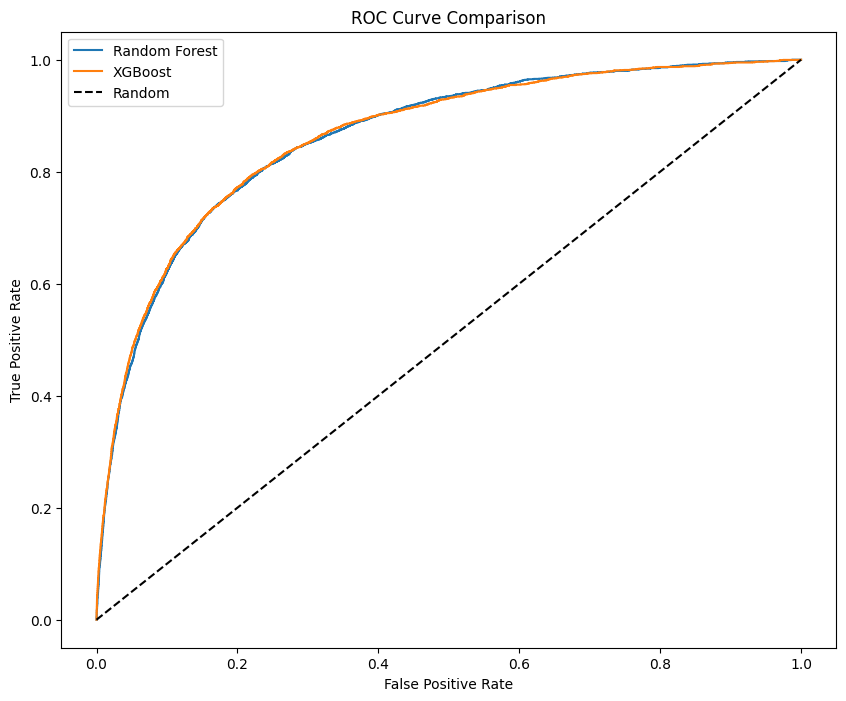

In [50]:
# ROC Curve comparison
plt.figure(figsize=(10, 8))
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_pred_prob)
plt.plot(fpr_rf, tpr_rf, label='Random Forest', linestyle='-')
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost', linestyle='-')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [44]:
# === Portfolio Analysis ===
# Assume higher score = safer customer (1 - default probability)
df_eval = X_test.copy()
df_eval['default_prob'] = xgb_pred_prob
df_eval['actual_default'] = y_test.values

# Sort by predicted risk
df_eval = df_eval.sort_values(by='default_prob', ascending=True)

# Calculate cumulative metrics
df_eval['cumulative_defaults'] = df_eval['actual_default'].cumsum()
df_eval['cumulative_population'] = np.arange(1, len(df_eval)+1)
df_eval['default_rate'] = df_eval['cumulative_defaults'] / df_eval['cumulative_population']


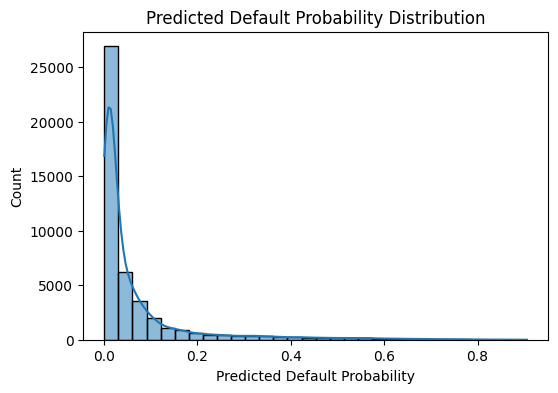

In [45]:
# === Visualization: Risk Distribution ===
plt.figure(figsize=(6,4))
sns.histplot(df_eval['default_prob'], bins=30, kde=True)
plt.title("Predicted Default Probability Distribution")
plt.xlabel("Predicted Default Probability")
plt.show()

In [46]:
# === Strategy Optimization Simulation ===
# Example: Evaluate cutoff thresholds (e.g., approve top X%)
thresholds = np.linspace(0.1, 0.9, 9)
results = []
for t in thresholds:
    approved = df_eval[df_eval['default_prob'] < t]
    reject_rate = 1 - len(approved)/len(df_eval)
    default_rate = approved['actual_default'].mean()
    results.append({'threshold': t, 'approval_rate': 1-reject_rate, 'portfolio_default_rate': default_rate})

results_df = pd.DataFrame(results)

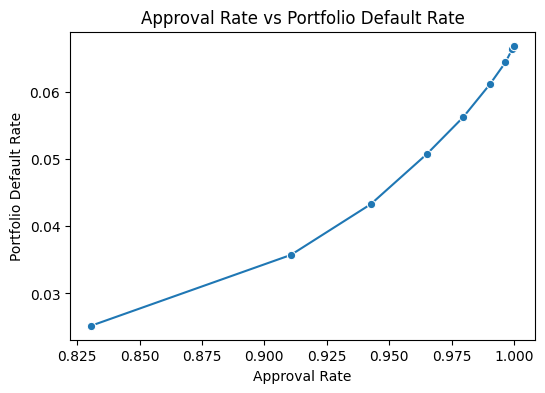

In [47]:
# === Visualize Strategy Tradeoff ===
plt.figure(figsize=(6,4))
sns.lineplot(data=results_df, x='approval_rate', y='portfolio_default_rate', marker='o')
plt.title("Approval Rate vs Portfolio Default Rate")
plt.xlabel("Approval Rate")
plt.ylabel("Portfolio Default Rate")
plt.show()

In [48]:
best_threshold = results_df.loc[results_df['portfolio_default_rate'].idxmin()]
print("\n=== Strategy Recommendation ===")
print(f"Optimal approval threshold: {best_threshold['threshold']:.2f}")
print(f"Expected approval rate: {best_threshold['approval_rate']:.2%}")
print(f"Expected portfolio default rate: {best_threshold['portfolio_default_rate']:.2%}")



=== Strategy Recommendation ===
Optimal approval threshold: 0.10
Expected approval rate: 83.06%
Expected portfolio default rate: 2.52%
